# Heart Disease Risk Prediction: Logistic Regression Homework

## Setup

In [1]:
%pip install matplotlib pandas numpy 


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ----------------- ---------------------- 4.2/9.9 MB 23.2 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.9 MB 25.9 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 22.8 MB/s  0:00:00

   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [panda


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


## Load and Prepare the Dataset

In [3]:
df = pd.read_csv("Heart_Disease_Prediction.csv")  
df.head()



,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    str    
dtypes: float64(1), int64(12), str(1)
memo

In [5]:
df.describe()


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


### Target Variable

The target variable of this dataset is **heart disease**, which indicates whether a patient has heart disease or not.

- **Presence (1)**: The patient has heart disease  
- **Absence (0)**: The patient does not have heart disease  




In [6]:
df['Heart Disease'] = df['Heart Disease'].map({
    'Presence': 1,
    'Absence': 0
})
df['Heart Disease'].value_counts()


Heart Disease
0    150
1    120
Name: count, dtype: int64

### Outliers

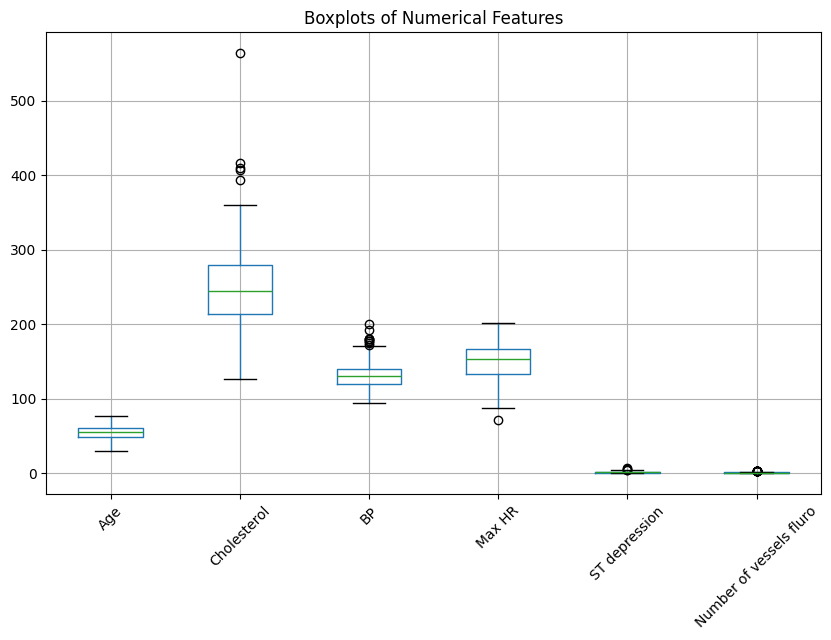

In [7]:
numerical_cols = [
    'Age',
    'Cholesterol',
    'BP',
    'Max HR',
    'ST depression',
    'Number of vessels fluro'
]

plt.figure(figsize=(10,6))
df[numerical_cols].boxplot()
plt.xticks(rotation=45)
plt.title("Boxplots of Numerical Features")
plt.show()



### Distribution


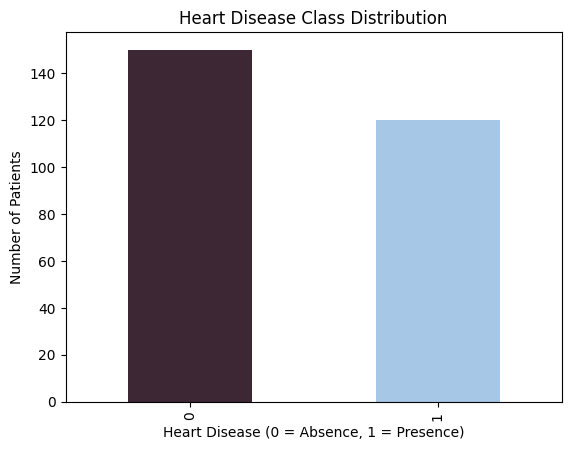

In [8]:
df['Heart Disease'].value_counts().plot(
    kind='bar',
    color=['#3e2734', '#A7C7E7']  
)

plt.title("Heart Disease Class Distribution")
plt.xlabel("Heart Disease (0 = Absence, 1 = Presence)")
plt.ylabel("Number of Patients")
plt.show()


### Feature Selection
Based on domain knowledge, we select numerical features commonly associated
with heart disease risk.

In [9]:
features = [
    'Age',
    'Cholesterol',
    'BP',
    'Max HR',
    'ST depression',
    'Number of vessels fluro'
]

X = df[features].values
y = df['Heart Disease'].values.reshape(-1, 1)

print(X.shape, y.shape)


(270, 6) (270, 1)


### Train-Test Split (70/30 Stratified)


In [10]:
def train_test_split_stratified(X, y, test_size=0.3):
    idx_0 = np.where(y.flatten() == 0)[0]
    idx_1 = np.where(y.flatten() == 1)[0]

    np.random.shuffle(idx_0)
    np.random.shuffle(idx_1)

    split_0 = int(len(idx_0) * (1 - test_size))
    split_1 = int(len(idx_1) * (1 - test_size))

    train_idx = np.concatenate([idx_0[:split_0], idx_1[:split_1]])
    test_idx = np.concatenate([idx_0[split_0:], idx_1[split_1:]])

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


In [11]:
X_train, X_test, y_train, y_test = train_test_split_stratified(X, y)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (189, 6)
Test size: (81, 6)


### Feature Normalization



In [12]:
def normalize(X):
    mu = X.mean(axis=0)
    sigma = X.std(axis=0)
    return (X - mu) / sigma, mu, sigma


In [13]:
X_train, mu, sigma = normalize(X_train)
X_test = (X_test - mu) / sigma


## Logistic Regression From Scratch
### Sigmoid Function


In [14]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


### Cost Function


In [15]:
def compute_cost(X, y, w, b):
    m = X.shape[0]
    z = X @ w + b
    y_hat = sigmoid(z)
    cost = -(1/m) * np.sum(
        y * np.log(y_hat + 1e-8) +
        (1 - y) * np.log(1 - y_hat + 1e-8)
    )
    return cost


### Gradient Descent Optimization


In [16]:
def gradient_descent(X, y, lr=0.01, iterations=2000):
    m, n = X.shape
    w = np.zeros((n, 1))
    b = 0
    costs = []

    for i in range(iterations):
        z = X @ w + b
        y_hat = sigmoid(z)

        dw = (1/m) * (X.T @ (y_hat - y))
        db = (1/m) * np.sum(y_hat - y)

        w -= lr * dw
        b -= lr * db

        costs.append(compute_cost(X, y, w, b))

    return w, b, costs


### Model Training


In [17]:
w, b, costs = gradient_descent(X_train, y_train)


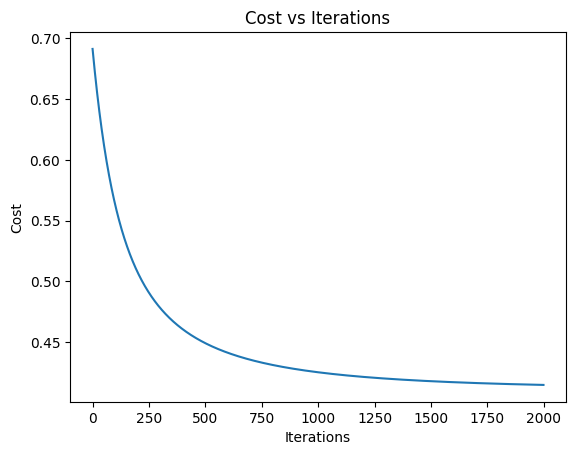

In [18]:
plt.figure()
plt.plot(costs)
plt.title("Cost vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()


### Prediction and Evaluation Metrics


In [19]:
def predict(X, w, b):
    probs = sigmoid(X @ w + b)
    return (probs >= 0.5).astype(int)


In [20]:
def metrics(y_true, y_pred):
    acc = np.mean(y_true == y_pred)

    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    return acc, precision, recall, f1


In [21]:
y_train_pred = predict(X_train, w, b)
y_test_pred = predict(X_test, w, b)

print("Train Metrics:", metrics(y_train, y_train_pred))
print("Test Metrics:", metrics(y_test, y_test_pred))


Train Metrics: (np.float64(0.8095238095238095), np.float64(0.8157894735768699), np.float64(0.7380952380073696), np.float64(0.7749999949156251))
Test Metrics: (np.float64(0.7283950617283951), np.float64(0.705882352733564), np.float64(0.6666666664814814), np.float64(0.6857142805224491))


In [22]:
metrics_table = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Accuracy": [
        metrics(y_train, y_train_pred)[0],
        metrics(y_test, y_test_pred)[0]
    ],
    "Precision": [
        metrics(y_train, y_train_pred)[1],
        metrics(y_test, y_test_pred)[1]
    ],
    "Recall": [
        metrics(y_train, y_train_pred)[2],
        metrics(y_test, y_test_pred)[2]
    ],
    "F1-score": [
        metrics(y_train, y_train_pred)[3],
        metrics(y_test, y_test_pred)[3]
    ]
})

metrics_table


,Dataset,Accuracy,Precision,Recall,F1-score
0,Train,0.809524,0.815789,0.738095,0.775000
1,Test,0.728395,0.705882,0.666667,0.685714




The logistic regression model achieves comparable performance on both the
training and test sets, suggesting good generalization and limited overfitting.

- **Accuracy** indicates that the model correctly classifies most patients.
- **Precision** reflects the reliability of positive heart disease predictions.
- **Recall** is particularly important in this medical context, as it measures
  the model’s ability to correctly identify patients with heart disease.
- **F1-score** balances precision and recall, providing a robust overall metric.

The relatively stable performance across datasets indicates that the model
captures meaningful patterns in the data.


In [23]:
weights_df = pd.DataFrame({
    "Feature": features,
    "Weight": w.flatten()
}).sort_values(by="Weight", ascending=False)

weights_df


,Feature,Weight
5,Number of vessels fluro,1.052139
4,ST depression,0.858468
1,Cholesterol,0.142570
2,BP,0.141121
0,Age,-0.083385
3,Max HR,-0.787813


### Interpretation of Learned Weights

The learned coefficients represent the influence of each feature on the
probability of heart disease.

- Positive weights increase the likelihood of heart disease presence.
- Negative weights decrease the likelihood.

Features such as cholesterol levels, ST depression, and number of vessels
fluoroscopically colored show stronger absolute weights, indicating higher
predictive influence. This aligns with established clinical risk factors for
cardiovascular disease.

Since the features were normalized, the magnitude of the weights can be
directly compared.
